# Optimizer Comparison: SGD, Momentum, and Adam

A from-scratch implementation of three gradient-descent optimizers on a binary classification task.  
We build the model, loss, and each optimizer by hand — then compare convergence speed and final decision boundaries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('ggplot')

In [3]:
# ── 1. Synthetic dataset ───────────────────────────────────────────
rng = np.random.default_rng(42)
n = 100                              # samples
X = rng.normal(size=(n, 2))          # 2 features
w_true = np.array([1.5, -2.0])
b_true = 0.5
logits = X @ w_true + b_true
y = (logits > 0).astype(float)   # binary labels

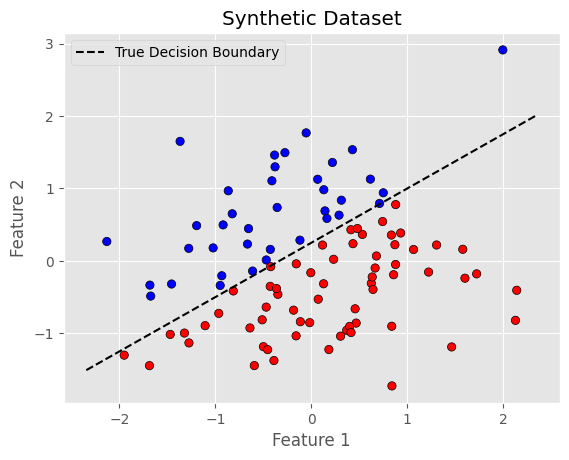

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
# decision boundaries: w[0]*x1 + w[1]*x2 + b = 0 => x2 = -(w[0]*x1 + b) / w[1]
x_vals = np.array(plt.gca().get_xlim())
y_vals = -(w_true[0] * x_vals + b_true) / w_true[1]
plt.plot(x_vals, y_vals, 'k--', label='True Decision Boundary')
plt.legend()
plt.title('Synthetic Dataset');

In [5]:
# ── 2. Model ─────────────────────────────────────────────
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -100, 100)))

def forward(X, w, b):
    return sigmoid(X @ w + b)          # shape (n,)

### Manual gradients vs. PyTorch autograd

Here the gradients are **derived analytically by hand** and hard-coded:
- `dw = X.T @ err / n` — result of applying the chain rule on paper
- `db = err.mean()`

**PyTorch** instead builds a **dynamic computation graph** during the forward pass,
then calls `.backward()` to traverse it automatically (backpropagation):

```python
# PyTorch equivalent
yhat = torch.sigmoid(X @ w + b)   # graph built here
loss = -torch.mean(y*torch.log(yhat) + (1-y)*torch.log(1-yhat))
loss.backward()                   # gradients computed automatically
# w.grad ≈ dw,  b.grad ≈ db
```

The manual approach works for simple models. For deep networks with 50+ layers,
deriving gradients by hand is impractical — that's the whole point of autograd.
The dynamic graph also handles arbitrary control flow (`if`, `for`) at runtime.

In [6]:
# ── 3. Loss + gradient ─────────────────────────────────────────────
def loss_and_grad(X, y, w, b):
    yhat   = forward(X, w, b)          # predictions (activation + linear)
    loss   = -np.mean(y*np.log(yhat+1e-9) + (1-y)*np.log(1-yhat+1e-9)) # binary cross-entropy 
    
    err    = yhat - y                  # (n,)  ← residual
    dw     = X.T @ err / n             # (d,)  ← ∂L/∂w = 1/n X^T (yhat - y)  
    db     = err.mean()                # scalar ← ∂L/∂b = mean(yhat - y) 
    return loss, dw, db

## Adam — step by step

Adam (Adaptive Moment Estimation) says: RMSProp is good but it has no momentum. Momentum is good but it has no adaptivity. What if we combine both, and fix a subtle initialisation bug that affects both?

---

### Step 1 — First moment (momentum)

The first moment is the mean of recent gradients — exactly what momentum tracks:

$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$$

- $m_t$ — biased mean of recent gradients. Starts at $m_0 = 0$.
- $\beta_1$ — decay rate (typically **0.9**). Same role as $\beta$ in regular momentum.
- $(1 - \beta_1)$ — weight on the new gradient.
- $g_t$ — current gradient.

This is identical to momentum, written as an EMA rather than a raw accumulation.

---

### Step 2 — Second moment (adaptivity)

The second moment is the mean of recent **squared** gradients — exactly what RMSProp tracks:

$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$$

- $v_t$ — biased mean of $g_t^2$. Starts at $v_0 = 0$.
- $\beta_2$ — decay rate (typically **0.999**). Much closer to 1 than $\beta_1$, giving a memory of roughly $\frac{1}{1-0.999} = 1000$ steps — a stable estimate of gradient variance.
- $g_t^2$ — squared gradient, measuring magnitude regardless of sign.

---

### Step 3 — Bias correction

Both $m_0 = 0$ and $v_0 = 0$. This is a problem.

At $t=1$: $m_1 = (1 - \beta_1) \cdot g_1 = 0.1 \cdot g_1$ — only **10% of the actual gradient**. In general, the EMA after $t$ steps approximates $\mu_g \cdot (1 - \beta_1^t)$, so the initialisation at zero pulls every early estimate toward zero.

The correction is algebraically exact — divide by the bias factor:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

The hat $\hat{\,}$ means "bias-corrected estimate".

- At $t=1$: divide by $0.1$ (i.e. multiply by 10) — fully undoes the underestimate.
- At $t=100$: $1 - 0.9^{100} \approx 1.0$ — correction nearly disappears, the initialisation bias is long gone.

> This is not a hack. It is an exact correction derived from the expectation of the EMA under a stationary gradient distribution.

---

### Step 4 — Final update

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

| Symbol | What it is | Typical value |
|---|---|---|
| $\theta_t$ | Current parameters | initialised randomly |
| $\eta$ | Base learning rate | 0.001 |
| $\hat{m}_t$ | Bias-corrected gradient mean (direction + momentum) | computed |
| $\hat{v}_t$ | Bias-corrected gradient variance | computed |
| $\sqrt{\hat{v}_t}$ | RMS of recent gradients — how noisy/large this parameter's gradient is | computed |
| $\epsilon$ | Numerical stability constant | $10^{-8}$ |
| $\beta_1$ | Momentum decay | 0.9 |
| $\beta_2$ | Variance decay | 0.999 |

The numerator $\hat{m}_t$ provides direction and momentum. The denominator $\sqrt{\hat{v}_t}$ normalises by gradient scale — making the effective step size roughly $\eta$ regardless of how large the raw gradients are. The result is an update that is both **smooth** (from momentum) and **self-calibrated per parameter** (from the second moment).

### Adam vs AdamW — L2 regularization vs weight decay

Adam alone tends to overfit: like any optimizer, it will happily drive weights to large values if that reduces the training loss. The classic fix is **L2 regularization** — add a penalty on the squared weights to the loss:

$$L_{reg}(\theta) = L(\theta) + \frac{\lambda}{2}\|\theta\|^2 \quad\Rightarrow\quad g_t = \nabla_\theta L(\theta_t) + \lambda \theta_t$$

The point is simple: without it, nothing stops weights from growing arbitrarily large to chase small reductions in training loss — large weights make the model overly sensitive to individual features/inputs, which hurts generalization. Penalizing $\|\theta\|^2$ keeps weights small unless the data really justifies them.

**"Adam with L2 regularization"** — the naive and, until ~2019, standard way to do this — just folds $\lambda\theta_t$ into $g_t$ *before* computing $m_t$ and $v_t$ (Step 1–2 above). That's the problem: $v_t$ is the EMA of $g_t^2$, so for parameters with large natural gradients (large $v_t$), the $\lambda\theta_t$ term gets divided by a large $\sqrt{\hat v_t}$ in Step 4 and is effectively *cancelled out*. For parameters with small gradients, it passes through almost unattenuated. The result: the actual amount of regularization applied to each weight depends on that weight's gradient history — not on the weight's own magnitude, which is what L2 was supposed to control in the first place.

**AdamW** (Loshchilov & Hutter, 2019) fixes this by **decoupling** weight decay from the adaptive gradient estimate: $\lambda\theta_t$ is *never* mixed into $g_t$, $m_t$, or $v_t$. Instead it's applied directly to the parameters at Step 4, after the adaptive update:

$$\theta_{t+1} = \theta_t - \eta\left(\frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon} + \lambda \theta_t\right)$$

Now every weight shrinks by the same relative factor $\eta\lambda$ every step, regardless of $\hat v_t$ — a true weight decay, not an L2 penalty distorted by per-parameter adaptivity. This is why AdamW generalizes better in practice and is the default choice for training most modern deep nets (transformers included).

In [7]:
# ── 4. Optimisers ──────────────────────────────────────────────────
class SGD:
    def __init__(self, lr=0.1):
        self.lr = lr
        
    def step(self, w, b, dw, db):
        w = w - self.lr * dw
        b = b - self.lr * db
        return w, b


class Momentum:
    def __init__(self, lr=0.1, beta=0.9):
        self.lr, self.beta = lr, beta
        self.vw = np.zeros_like(w_true) # velocity for weights — allocated on first step
        self.vb = 0.0
        
    def step(self, w, b, dw, db):
        self.vw = self.beta*self.vw + dw
        self.vb = self.beta*self.vb + db
        w = w - self.lr * self.vw
        b = b - self.lr * self.vb
        return w, b
    

class Adam:
    def __init__(self, lr=0.01, b1=0.9, b2=0.999, eps=1e-8, weight_decay=0.0, adamw=False):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.weight_decay, self.adamw = weight_decay, adamw  # adamw=True → decoupled decay instead of L2
        self.mw = self.vw = np.zeros_like(w_true) # 1st/2nd moment — allocated on first step
        self.mb = self.vb = 0.0
        self.t  = 0 # step counter for bias correction

    def step(self, w, b, dw, db):
        self.t += 1
        if self.weight_decay and not self.adamw:   # classic Adam+L2: fold into the gradient
            dw = dw + self.weight_decay * w
        # 1st moment
        self.mw = self.b1*self.mw + (1-self.b1)*dw
        self.mb = self.b1*self.mb + (1-self.b1)*db
        # 2nd moment
        self.vw = self.b2*self.vw + (1-self.b2)*dw**2
        self.vb = self.b2*self.vb + (1-self.b2)*db**2
        # bias correction
        mw_hat = self.mw / (1 - self.b1**self.t)
        mb_hat = self.mb / (1 - self.b1**self.t)
        vw_hat = self.vw / (1 - self.b2**self.t)
        vb_hat = self.vb / (1 - self.b2**self.t)
        # update
        w = w - self.lr * mw_hat / (np.sqrt(vw_hat) + self.eps)
        b = b - self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)
        if self.weight_decay and self.adamw:        # AdamW: decoupled decay, applied straight to the weights
            w = w - self.lr * self.weight_decay * w
        return w, b

In [8]:
# ── 5. Training loop ───────────────────────────────────────────────
def train(opt, epochs=1000):
    w = rng.normal(size=(2,)) * 0.01   # small random init
    b = 0.0
    history = []
    for _ in range(epochs):
        loss, dw, db = loss_and_grad(X, y, w, b)
        w, b = opt.step(w, b, dw, db)
        history.append(loss)
    return history, w, b

h_sgd, w_sgd, b_sgd  = train(SGD(lr=0.5))
h_mom, w_mom, b_mom  = train(Momentum(lr=0.1, beta=0.9))
h_adam, w_adam, b_adam = train(Adam(lr=0.04))
h_adamw, w_adamw, b_adamw = train(Adam(lr=0.04, weight_decay=0.01, adamw=True))

In [9]:
# table of final parameters
def get_ratio(w, b):
    return round(-w[0]/w[1], 2), round(-b/w[1], 2)  # from decision boundary: w[0]*x1 + w[1]*x2 + b = 0 => x2 = -(w[0]*x1 + b) / w[1]

table_weights = pd.DataFrame({
    'Optimizer': ['SGD', 'Momentum', 'Adam', 'AdamW', "True"],
    'w1': [w_sgd[0], w_mom[0], w_adam[0], w_adamw[0], w_true[0]],
    'w2': [w_sgd[1], w_mom[1], w_adam[1], w_adamw[1], w_true[1]],
    'b':  [b_sgd, b_mom, b_adam, b_adamw, b_true],
    "ratio(w, b)": [get_ratio(w_sgd, b_sgd), 
                    get_ratio(w_mom, b_mom), 
                    get_ratio(w_adam, b_adam), 
                    get_ratio(w_adamw, b_adamw),
                    get_ratio(w_true, b_true)]
})
table_weights

,Optimizer,w1,w2,b,"ratio(w, b)"
0,SGD,5.591415,-8.207812,2.068499,"(0.68, 0.25)"
1,Momentum,7.377845,-10.664150,2.649586,"(0.69, 0.25)"
2,Adam,7.142365,-10.212641,2.576689,"(0.7, 0.25)"
3,AdamW,6.180761,-8.873033,2.268504,"(0.7, 0.26)"
4,True,1.500000,-2.000000,0.500000,"(0.75, 0.25)"


In [10]:
# 6. scoring final parameters
def score(w, b, X=X, y=y):
    yhat = forward(X, w, b) > 0.5
    return (yhat == y).mean()

sgd_score  = score(w_sgd, b_sgd)
mom_score  = score(w_mom, b_mom)
adam_score = score(w_adam, b_adam)
adamw_score = score(w_adamw, b_adamw)

In [11]:
table_scores = pd.DataFrame({
    'Optimizer': ['SGD', 'Momentum', 'Adam', 'AdamW'],
    'Accuracy': [sgd_score, mom_score, adam_score, adamw_score]
})
table_scores

,Optimizer,Accuracy
0,SGD,1.0
1,Momentum,1.0
2,Adam,1.0
3,AdamW,1.0


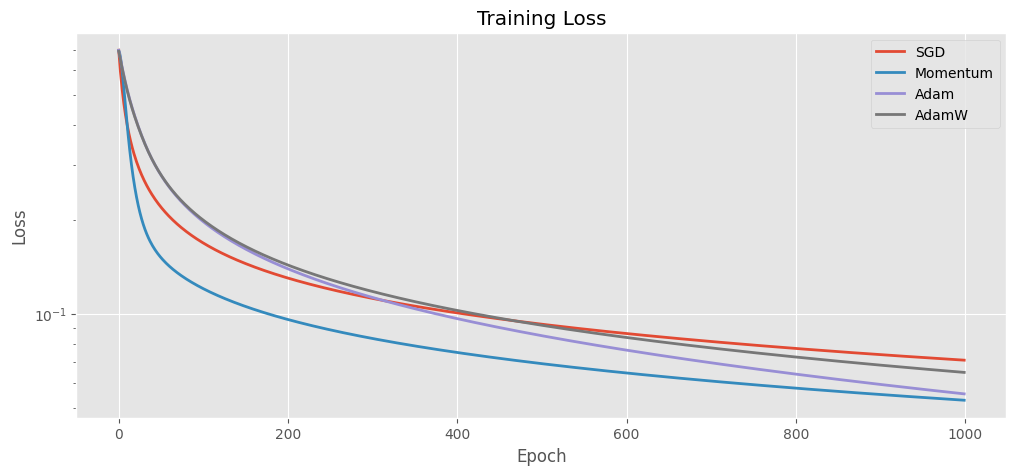

In [17]:
# ── 7. Visualization ───────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(h_sgd, label='SGD', linewidth=2)
plt.plot(h_mom, label='Momentum', linewidth=2)
plt.plot(h_adam, label='Adam', linewidth=2)
plt.plot(h_adamw, label='AdamW', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

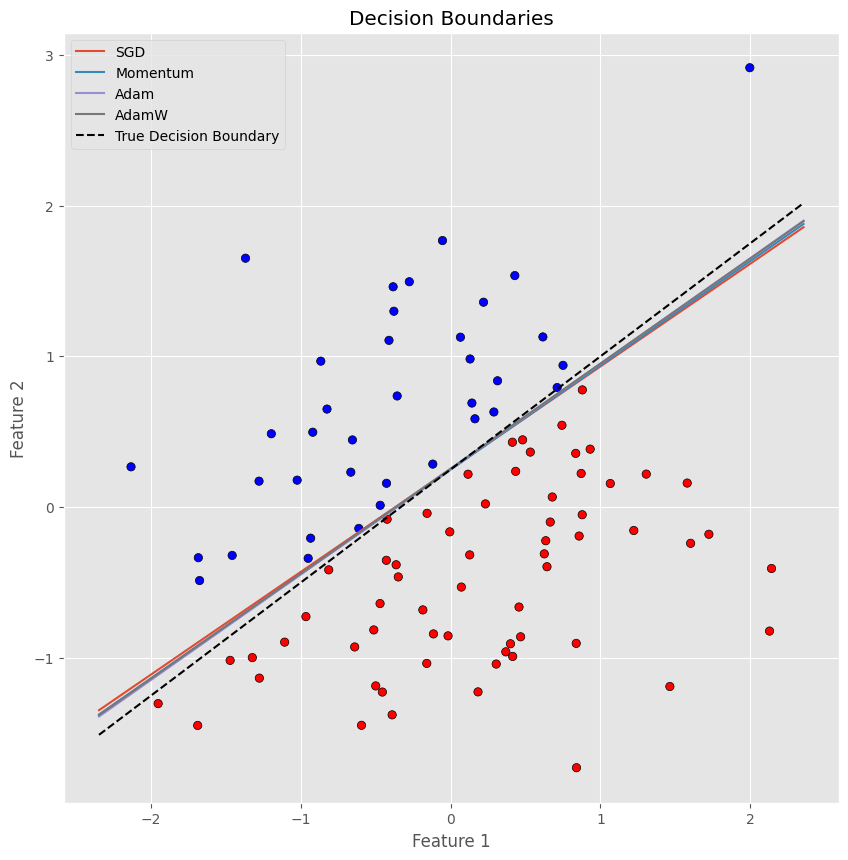

In [15]:
# Decision boundaries
plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')

x_vals = np.array(plt.gca().get_xlim())
y_sgd  = -(w_sgd[0] * x_vals + b_sgd)/w_sgd[1]
y_mom  = -(w_mom[0] * x_vals + b_mom)/w_mom[1]
y_adam = -(w_adam[0] * x_vals + b_adam)/w_adam[1]
y_adamw = -(w_adamw[0] * x_vals + b_adamw)/w_adamw[1]
plt.plot(x_vals, y_sgd, label='SGD')
plt.plot(x_vals, y_mom, label='Momentum')
plt.plot(x_vals, y_adam, label='Adam')
plt.plot(x_vals, y_adamw, label='AdamW')
plt.plot(x_vals, y_vals, 'k--', label='True Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundaries')
plt.legend()